# Previsão de Churn de Clientes

**Objetivo:** construir um pipeline completo de ciência de dados para prever clientes com maior risco de churn, combinando EDA, limpeza, engenharia de atributos, comparação de modelos, explicabilidade com SHAP e recomendações acionáveis de negócio.

Este notebook foi estruturado como um projeto de portfólio para GitHub, com uma abordagem próxima de um fluxo de trabalho profissional: primeiro entendo os dados, depois valido qualidade, crio hipóteses, treino modelos, explico as decisões do modelo e transformo os achados em ações para retenção.

---

## Sumário

1. Setup e carregamento dos dados  
2. Auditoria de qualidade dos dados  
3. Análise exploratória  
4. Engenharia de atributos  
5. Checagem de drift entre treino e teste  
6. Modelagem e comparação de algoritmos  
7. Ajuste de threshold e avaliação final  
8. Explicabilidade com SHAP  
9. Recomendações de negócio  
10. Exportação do pipeline para deploy

In [1]:
# ============================================================
# 1. SETUP
# ============================================================

from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Visual padrão do projeto
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

# Detecta a raiz do projeto mesmo quando o notebook roda dentro da pasta /notebooks
def detect_project_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/mnt/data/churn_customer_project"),  # fallback deste ambiente
    ]
    for candidate in candidates:
        if (candidate / "README.md").exists() and (candidate / "notebooks").exists():
            return candidate
    # Fallback local: se estiver dentro de /notebooks, volta um nível.
    if Path.cwd().name == "notebooks":
        return Path.cwd().parent
    return Path.cwd()

PROJECT_ROOT = detect_project_root()
PROJECT_ROOT

WindowsPath('c:/Users/conta/OneDrive/Desktop/Projetos/Previsão de Churn de Clientes/churn_customer_project')

In [2]:
# ============================================================
# 2. CARREGAMENTO DOS DADOS
# ============================================================

TRAIN_CANDIDATES = [
    PROJECT_ROOT / "data" / "raw" / "customer_churn_dataset-training-master.csv",
    PROJECT_ROOT / "customer_churn_dataset-training-master.csv",
    Path("/mnt/data/customer_churn_dataset-training-master.csv"),  # fallback para execução neste ambiente
]

TEST_CANDIDATES = [
    PROJECT_ROOT / "data" / "raw" / "customer_churn_dataset-testing-master.csv",
    PROJECT_ROOT / "customer_churn_dataset-testing-master.csv",
    Path("/mnt/data/customer_churn_dataset-testing-master.csv"),  # fallback para execução neste ambiente
]


def find_existing_file(candidates):
    """Retorna o primeiro caminho existente de uma lista de candidatos."""
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Arquivo não encontrado. Coloque os CSVs em data/raw/ ou ajuste os caminhos no notebook."
    )

train_path = find_existing_file(TRAIN_CANDIDATES)
test_path = find_existing_file(TEST_CANDIDATES)

raw_train = pd.read_csv(train_path)
raw_test = pd.read_csv(test_path)

print(f"Treino: {raw_train.shape[0]:,} linhas x {raw_train.shape[1]} colunas")
print(f"Teste:  {raw_test.shape[0]:,} linhas x {raw_test.shape[1]} colunas")
print(f"Arquivo de treino: {train_path}")
print(f"Arquivo de teste:  {test_path}")

display(raw_train.head())

Treino: 440,833 linhas x 12 colunas
Teste:  64,374 linhas x 12 colunas
Arquivo de treino: c:\Users\conta\OneDrive\Desktop\Projetos\Previsão de Churn de Clientes\churn_customer_project\data\raw\customer_churn_dataset-training-master.csv
Arquivo de teste:  c:\Users\conta\OneDrive\Desktop\Projetos\Previsão de Churn de Clientes\churn_customer_project\data\raw\customer_churn_dataset-testing-master.csv


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0000,30.0000,Female,39.0000,14.0000,5.0000,18.0000,Standard,Annual,932.0000,17.0000,1.0000
1,3.0000,65.0000,Female,49.0000,1.0000,10.0000,8.0000,Basic,Monthly,557.0000,6.0000,1.0000
2,4.0000,55.0000,Female,14.0000,4.0000,6.0000,18.0000,Basic,Quarterly,185.0000,3.0000,1.0000
3,5.0000,58.0000,Male,38.0000,21.0000,7.0000,7.0000,Standard,Monthly,396.0000,29.0000,1.0000
4,6.0000,23.0000,Male,32.0000,20.0000,5.0000,8.0000,Basic,Monthly,617.0000,20.0000,1.0000


## 1. Auditoria de qualidade dos dados

Antes de modelar, eu verifico inconsistências básicas: nomes de colunas, tipos, nulos, duplicidades e distribuição da variável alvo. Essa etapa evita que o modelo aprenda ruído ou que o pipeline quebre em produção.

In [3]:
# ============================================================
# 3. LIMPEZA INICIAL E PADRONIZAÇÃO
# ============================================================

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Padroniza nomes de colunas para snake_case."""
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.lower()
    )
    return df

train = standardize_columns(raw_train)
test = standardize_columns(raw_test)

# Remove linhas completamente vazias ou registros sem target.
# No treino existe uma linha com todos os campos nulos.
train = train.dropna(subset=["churn"]).reset_index(drop=True)
test = test.dropna(subset=["churn"]).reset_index(drop=True)

# O target deve ser inteiro binário.
train["churn"] = train["churn"].astype(int)
test["churn"] = test["churn"].astype(int)

# CustomerID é identificador, não deve entrar como variável preditiva.
ID_COL = "customerid"
TARGET = "churn"

print("Colunas padronizadas:")
print(train.columns.tolist())

display(train.head())

Colunas padronizadas:
['customerid', 'age', 'gender', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'subscription_type', 'contract_length', 'total_spend', 'last_interaction', 'churn']


,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,2.0000,30.0000,Female,39.0000,14.0000,5.0000,18.0000,Standard,Annual,932.0000,17.0000,1
1,3.0000,65.0000,Female,49.0000,1.0000,10.0000,8.0000,Basic,Monthly,557.0000,6.0000,1
2,4.0000,55.0000,Female,14.0000,4.0000,6.0000,18.0000,Basic,Quarterly,185.0000,3.0000,1
3,5.0000,58.0000,Male,38.0000,21.0000,7.0000,7.0000,Standard,Monthly,396.0000,29.0000,1
4,6.0000,23.0000,Male,32.0000,20.0000,5.0000,8.0000,Basic,Monthly,617.0000,20.0000,1


In [4]:
# ============================================================
# 4. RELATÓRIO DE QUALIDADE
# ============================================================

def data_quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    report = pd.DataFrame({
        "dataset": name,
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(4),
        "unique": df.nunique(dropna=True),
    })
    return report.sort_values("missing_%", ascending=False)

quality = pd.concat([
    data_quality_report(train, "train"),
    data_quality_report(test, "test")
])

display(quality)

print(f"IDs duplicados no treino: {train[ID_COL].duplicated().sum():,}")
print(f"IDs duplicados no teste:  {test[ID_COL].duplicated().sum():,}")
print(f"Churn rate treino: {train[TARGET].mean():.2%}")
print(f"Churn rate teste:  {test[TARGET].mean():.2%}")

,dataset,dtype,missing,missing_%,unique
customerid,train,float64,0,0.0000,440832
age,train,float64,0,0.0000,48
gender,train,str,0,0.0000,2
tenure,train,float64,0,0.0000,60
usage_frequency,train,float64,0,0.0000,30
support_calls,train,float64,0,0.0000,11
payment_delay,train,float64,0,0.0000,31
subscription_type,train,str,0,0.0000,3
contract_length,train,str,0,0.0000,3
total_spend,train,float64,0,0.0000,68363


IDs duplicados no treino: 0
IDs duplicados no teste:  0
Churn rate treino: 56.71%
Churn rate teste:  47.37%


## 2. Análise exploratória

Aqui eu busco padrões simples que ajudem a transformar a análise em hipóteses de negócio: clientes com mais chamados de suporte churnam mais? Atraso de pagamento tem relação com churn? Contratos mensais são mais sensíveis?

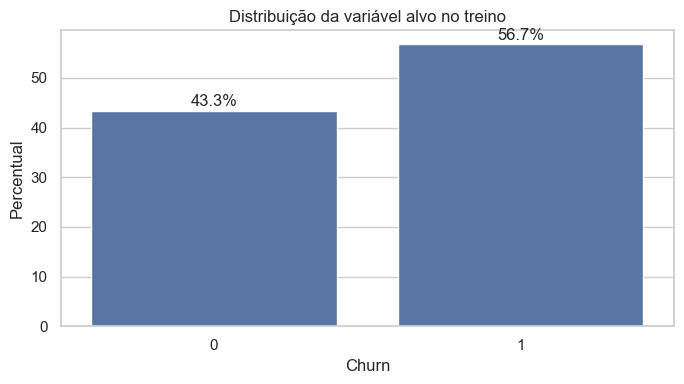

In [5]:
# ============================================================
# 5. EDA - DISTRIBUIÇÃO DO TARGET
# ============================================================

def add_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

fig, ax = plt.subplots(figsize=(7, 4))
churn_pct = train[TARGET].value_counts(normalize=True).sort_index().mul(100)
sns.barplot(x=churn_pct.index.astype(str), y=churn_pct.values, ax=ax, color=sns.color_palette("deep")[0])
ax.set_title("Distribuição da variável alvo no treino")
ax.set_xlabel("Churn")
ax.set_ylabel("Percentual")
for i, value in enumerate(churn_pct.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 6. EDA - ESTATÍSTICAS POR CLASSE
# ============================================================

numeric_cols = train.select_dtypes(include=["number"]).columns.drop([ID_COL, TARGET]).tolist()
categorical_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()

profile_by_churn = (
    train
    .groupby(TARGET)[numeric_cols]
    .agg(["mean", "median"])
    .T
    .round(2)
)

display(profile_by_churn)

churn                          0        1
age              mean    36.2600  41.7500
                 median  37.0000  42.0000
tenure           mean    32.2800  30.4700
                 median  33.0000  30.0000
usage_frequency  mean    16.2600  15.4600
                 median  17.0000  15.0000
support_calls    mean     1.5900   5.1400
                 median   1.0000   5.0000
payment_delay    mean    10.0200  15.2200
                 median  10.0000  15.0000
total_spend      mean   749.9500 541.2900
                 median 749.9800 534.0000
last_interaction mean    13.0100  15.6000
                 median  12.0000  16.0000

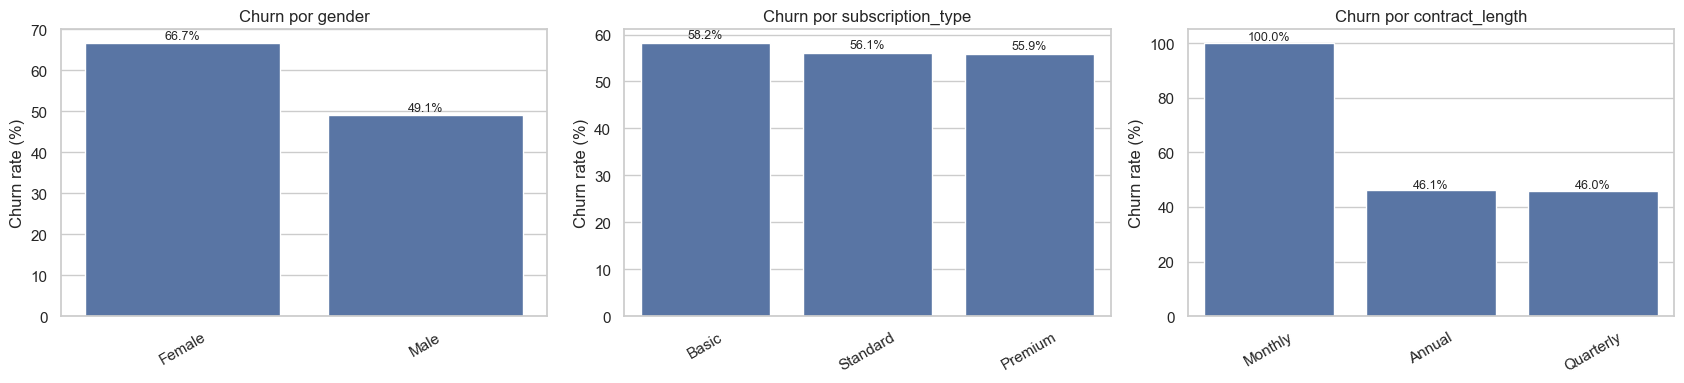

In [7]:
# ============================================================
# 7. EDA - TAXA DE CHURN POR CATEGORIA
# ============================================================

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(17, 4))
if len(categorical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    rate = (
        train.groupby(col)[TARGET]
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .reset_index(name="churn_rate")
    )
    sns.barplot(data=rate, x=col, y="churn_rate", ax=ax, color=sns.color_palette("deep")[0])
    ax.set_title(f"Churn por {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Churn rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for i, value in enumerate(rate["churn_rate"]):
        ax.text(i, value + 1, f"{value:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

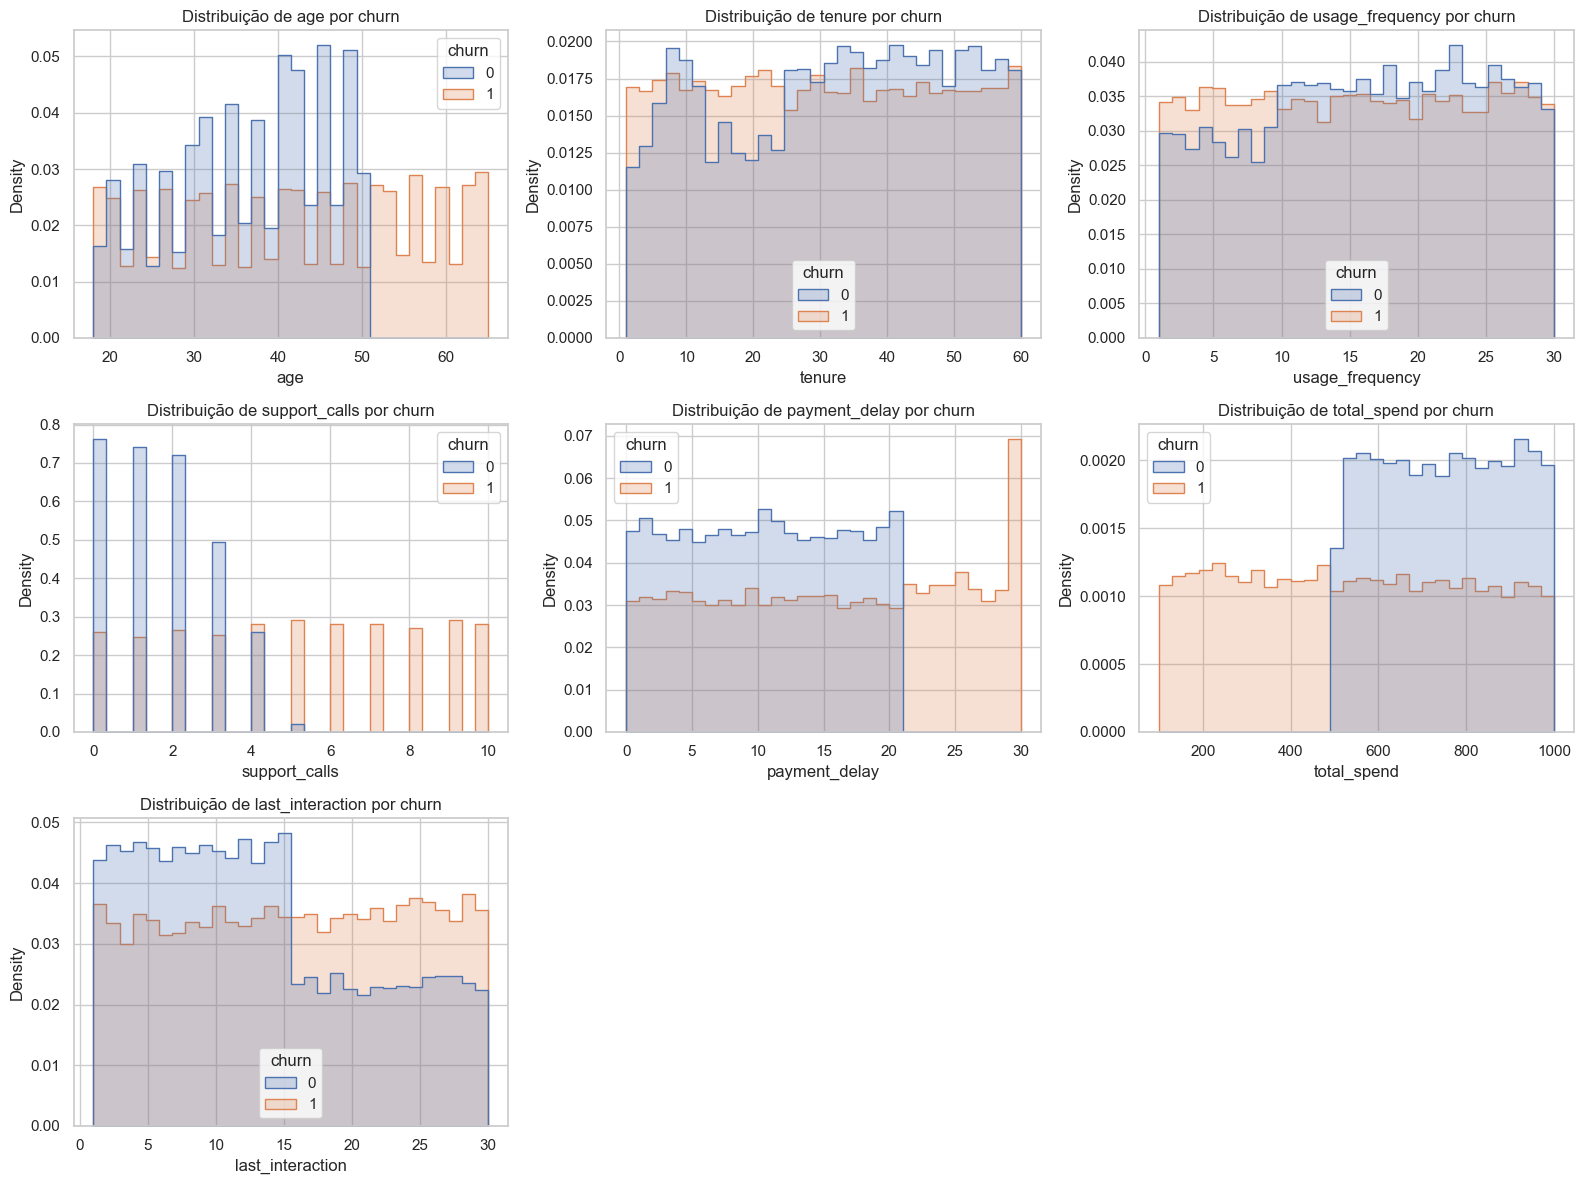

In [8]:
# ============================================================
# 8. EDA - DISTRIBUIÇÕES NUMÉRICAS
# ============================================================

# Amostra para gráficos mais leves sem perder leitura visual
eda_sample = train.sample(n=min(25_000, len(train)), random_state=RANDOM_STATE)

features_to_plot = [
    "age", "tenure", "usage_frequency", "support_calls",
    "payment_delay", "total_spend", "last_interaction"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, features_to_plot):
    sns.histplot(data=eda_sample, x=col, hue=TARGET, bins=30, stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title(f"Distribuição de {col} por churn")
    ax.set_xlabel(col)

for ax in axes[len(features_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

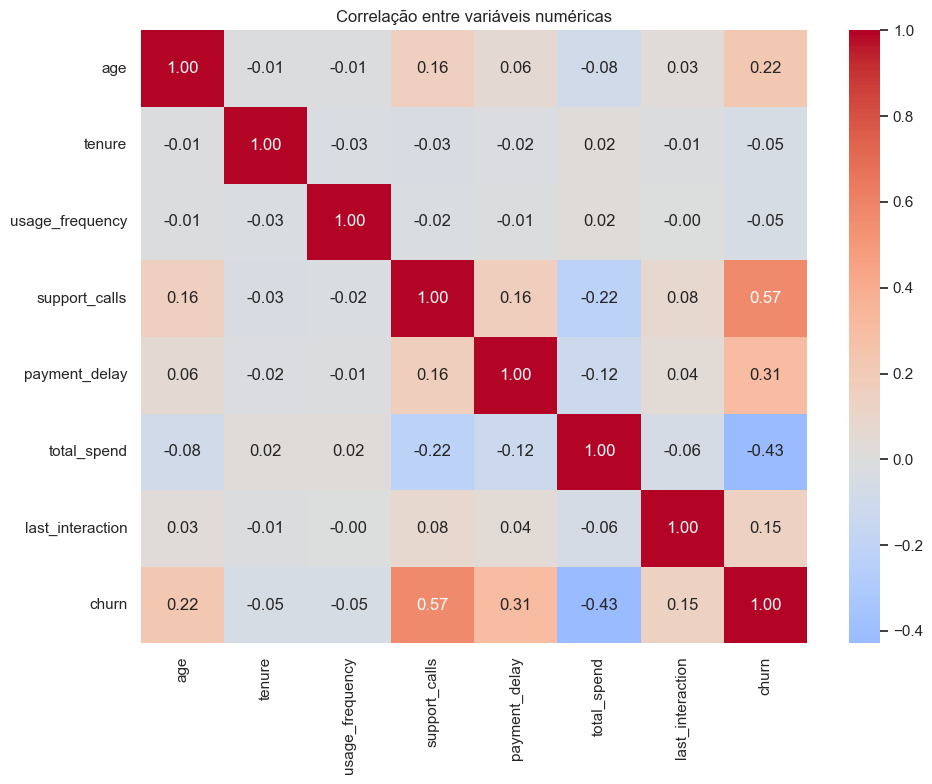

,corr_com_churn
support_calls,0.5743
total_spend,-0.4294
payment_delay,0.3121
age,0.2184
last_interaction,0.1496
tenure,-0.0519
usage_frequency,-0.0461


In [9]:
# ============================================================
# 9. EDA - CORRELAÇÃO COM CHURN
# ============================================================

corr = train[numeric_cols + [TARGET]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

corr_with_target = (
    corr[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_com_churn")
)

display(corr_with_target)

## 3. Engenharia de atributos

Além das variáveis originais, criei atributos que capturam intensidade e comportamento relativo. Exemplos:

- gasto médio por mês de relacionamento;
- chamados de suporte por mês;
- atraso de pagamento relativo ao tempo de relacionamento;
- score simples de engajamento;
- flags para clientes com alto suporte, baixo uso, atraso longo e contrato mensal.

In [10]:
# ============================================================
# 10. FEATURE ENGINEERING
# ============================================================

def add_business_features(df: pd.DataFrame) -> pd.DataFrame:
    """Cria features orientadas a negócio para churn."""
    df = df.copy()

    # Features de intensidade/normalização pelo tempo de relacionamento
    df["avg_spend_per_month"] = df["total_spend"] / (df["tenure"] + 1)
    df["support_calls_per_month"] = df["support_calls"] / (df["tenure"] + 1)
    df["payment_delay_rate"] = df["payment_delay"] / (df["tenure"] + 1)
    df["engagement_score"] = df["usage_frequency"] / (df["last_interaction"] + 1)

    # Flags interpretáveis para ações de retenção
    df["high_support_calls"] = (df["support_calls"] >= 5).astype(int)
    df["long_payment_delay"] = (df["payment_delay"] >= 15).astype(int)
    df["low_usage"] = (df["usage_frequency"] <= 10).astype(int)
    df["recently_inactive"] = (df["last_interaction"] >= 20).astype(int)
    df["month_to_month_contract"] = (
        df["contract_length"].astype(str).str.lower().str.contains("month")
    ).astype(int)

    return df

train_fe = add_business_features(train)
test_fe = add_business_features(test)

new_features = [
    "avg_spend_per_month", "support_calls_per_month", "payment_delay_rate",
    "engagement_score", "high_support_calls", "long_payment_delay",
    "low_usage", "recently_inactive", "month_to_month_contract"
]

display(train_fe[new_features + [TARGET]].head())

,avg_spend_per_month,support_calls_per_month,payment_delay_rate,engagement_score,high_support_calls,long_payment_delay,low_usage,recently_inactive,month_to_month_contract,churn
0,23.3000,0.1250,0.4500,0.7778,1,1,0,0,0,1
1,11.1400,0.2000,0.1600,0.1429,1,0,1,0,1,1
2,12.3333,0.4000,1.2000,1.0000,1,1,1,0,0,1
3,10.1538,0.1795,0.1795,0.7000,1,0,0,1,1,1
4,18.6970,0.1515,0.2424,0.9524,1,0,0,1,1,1


## 4. Checagem de drift entre treino e teste

Um ponto importante: o arquivo de teste não deve ser tratado apenas como “mais uma amostra igual ao treino”. Antes de confiar nos resultados finais, comparo a distribuição das variáveis entre treino e teste. Diferenças grandes podem indicar **data drift**, mudança de população ou amostragem distinta.

Usei PSI (*Population Stability Index*) como indicador simples:

- PSI < 0.10: baixo deslocamento;
- 0.10 a 0.25: atenção;
- > 0.25: deslocamento relevante.

,feature,psi_train_vs_test,drift_level
3,support_calls,0.3822,alto
4,payment_delay,0.2986,alto
8,support_calls_per_month,0.2487,atenção
5,total_spend,0.1611,atenção
0,age,0.1255,atenção
9,payment_delay_rate,0.1217,atenção
7,avg_spend_per_month,0.0871,baixo
10,engagement_score,0.0224,baixo
6,last_interaction,0.0167,baixo
2,usage_frequency,0.0111,baixo


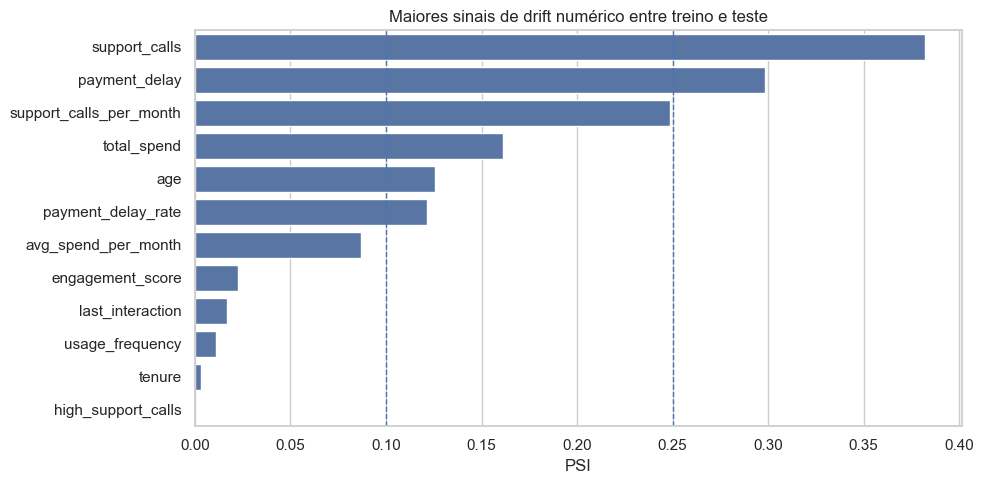

In [11]:
# ============================================================
# 11. POPULATION STABILITY INDEX - PSI
# ============================================================

def calculate_psi(expected: pd.Series, actual: pd.Series, buckets: int = 10) -> float:
    """Calcula PSI entre uma distribuição esperada e uma distribuição atual."""
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)

    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return np.nan

    quantiles = np.linspace(0, 100, buckets + 1)
    breakpoints = np.unique(np.percentile(expected, quantiles))

    if len(breakpoints) <= 2:
        return np.nan

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True, duplicates="drop")
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True, duplicates="drop")

    expected_pct = expected_bins.value_counts(normalize=True).sort_index()
    actual_pct = actual_bins.value_counts(normalize=True).sort_index()

    # Alinha os bins e evita divisão por zero
    dist = pd.concat([expected_pct, actual_pct], axis=1).fillna(0.0001)
    dist.columns = ["expected", "actual"]
    dist = dist.clip(lower=0.0001)

    psi = ((dist["actual"] - dist["expected"]) * np.log(dist["actual"] / dist["expected"])).sum()
    return float(psi)

feature_cols_all = [c for c in train_fe.columns if c not in [ID_COL, TARGET]]
numeric_features_all = train_fe[feature_cols_all].select_dtypes(include=["number"]).columns.tolist()

psi_table = pd.DataFrame({
    "feature": numeric_features_all,
    "psi_train_vs_test": [calculate_psi(train_fe[c], test_fe[c]) for c in numeric_features_all]
}).sort_values("psi_train_vs_test", ascending=False)

# Classificação simples para facilitar leitura
psi_table["drift_level"] = pd.cut(
    psi_table["psi_train_vs_test"],
    bins=[-np.inf, 0.10, 0.25, np.inf],
    labels=["baixo", "atenção", "alto"]
)

display(psi_table)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=psi_table.head(12), x="psi_train_vs_test", y="feature", ax=ax, color=sns.color_palette("deep")[0])
ax.axvline(0.10, linestyle="--", linewidth=1)
ax.axvline(0.25, linestyle="--", linewidth=1)
ax.set_title("Maiores sinais de drift numérico entre treino e teste")
ax.set_xlabel("PSI")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Modelagem

A estratégia de modelagem segue três cuidados:

1. **Baseline** para saber se o modelo realmente aprende algo além da classe majoritária.  
2. **Pipeline com preprocessamento** para evitar vazamento e facilitar deploy.  
3. **Comparação de modelos** usando métricas adequadas para churn: ROC-AUC, PR-AUC, recall, precisão e F1.

Como churn costuma ser um problema em que perder um cliente de alto risco pode ser caro, recall é importante. Ao mesmo tempo, precisão evita gastar incentivos com clientes sem risco real.

In [12]:
# ============================================================
# 12. MATRIZES DE FEATURES E SPLIT DE VALIDAÇÃO
# ============================================================

X = train_fe.drop(columns=[ID_COL, TARGET])
y = train_fe[TARGET].astype(int)

X_external_test = test_fe.drop(columns=[ID_COL, TARGET])
y_external_test = test_fe[TARGET].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

print(f"Treino interno:   {X_train.shape}")
print(f"Validação interna:{X_val.shape}")
print(f"Teste externo:    {X_external_test.shape}")
print(f"Numéricas: {len(numeric_features)} | Categóricas: {len(categorical_features)}")

Treino interno:   (352665, 19)
Validação interna:(88167, 19)
Teste externo:    (64374, 19)
Numéricas: 16 | Categóricas: 3


In [13]:
# ============================================================
# 13. PREPROCESSADORES
# ============================================================

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

numeric_transformer_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    verbose_feature_names_out=False,
)

preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_linear, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    verbose_feature_names_out=False,
)

In [14]:
# ============================================================
# 14. FUNÇÕES DE AVALIAÇÃO
# ============================================================

def get_scores(model, X_eval, y_eval, threshold: float = 0.5) -> dict:
    """Calcula métricas de classificação usando probabilidade e threshold configurável."""
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)[:, 1]
    else:
        proba = model.predict(X_eval)

    preds = (proba >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_eval, preds),
        "precision": precision_score(y_eval, preds, zero_division=0),
        "recall": recall_score(y_eval, preds, zero_division=0),
        "f1": f1_score(y_eval, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, proba),
        "pr_auc": average_precision_score(y_eval, proba),
    }


def evaluate_model(name, model, X_eval, y_eval, split: str, threshold: float = 0.5) -> dict:
    scores = get_scores(model, X_eval, y_eval, threshold=threshold)
    scores.update({"model": name, "split": split, "threshold": threshold})
    return scores


def plot_confusion_matrix(cm, title: str):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Não churn", "Churn"],
        yticklabels=["Não churn", "Churn"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
    plt.tight_layout()
    plt.show()

In [15]:
# ============================================================
# 15. TREINAMENTO E COMPARAÇÃO DE MODELOS
# ============================================================

model_specs = [
    (
        "Baseline",
        Pipeline(steps=[
            ("preprocess", preprocess_tree),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
    ),
    (
        "Logistic Regression",
        Pipeline(steps=[
            ("preprocess", preprocess_linear),
            ("model", LogisticRegression(
                max_iter=500,
                class_weight="balanced",
                n_jobs=1,
                random_state=RANDOM_STATE,
            )),
        ]),
    ),
    (
        "Decision Tree",
        Pipeline(steps=[
            ("preprocess", preprocess_tree),
            ("model", DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=100,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
    ),
]

if XGBOOST_AVAILABLE:
    model_specs.append(
        (
            "XGBoost",
            Pipeline(steps=[
                ("preprocess", preprocess_tree),
                ("model", XGBClassifier(
                    n_estimators=160,
                    max_depth=4,
                    learning_rate=0.07,
                    subsample=0.90,
                    colsample_bytree=0.90,
                    eval_metric="logloss",
                    tree_method="hist",
                    random_state=RANDOM_STATE,
                    n_jobs=1,  # evita travamentos em alguns ambientes e mantém reprodutibilidade
                )),
            ]),
        )
    )

trained_models = {}
validation_results = []
external_test_results = []

for name, model in model_specs:
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    trained_models[name] = model

    val_metrics = evaluate_model(name, model, X_val, y_val, split="validation")
    val_metrics["train_time_sec"] = elapsed
    validation_results.append(val_metrics)

    test_metrics = evaluate_model(name, model, X_external_test, y_external_test, split="external_test")
    test_metrics["train_time_sec"] = np.nan
    external_test_results.append(test_metrics)

results = (
    pd.DataFrame(validation_results + external_test_results)
    [["split", "model", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold", "train_time_sec"]]
    .sort_values(["split", "roc_auc"], ascending=[True, False])
)

styled_results = results.copy()
for col in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "threshold", "train_time_sec"]:
    styled_results[col] = styled_results[col].astype(float).round(4)

display(styled_results)

,split,model,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold,train_time_sec
7,external_test,XGBoost,0.5043,0.4886,0.9983,0.6561,0.7287,0.6515,0.5000,NaN
5,external_test,Logistic Regression,0.5762,0.5280,0.9921,0.6892,0.6977,0.6489,0.5000,NaN
6,external_test,Decision Tree,0.5101,0.4916,0.9981,0.6587,0.5343,0.4914,0.5000,NaN
4,external_test,Baseline,0.4737,0.4737,1.0000,0.6429,0.5000,0.4737,0.5000,NaN
3,validation,XGBoost,0.9989,1.0000,0.9981,0.9990,1.0000,1.0000,0.5000,66.9437
2,validation,Decision Tree,0.9937,0.9998,0.9891,0.9944,0.9969,0.9977,0.5000,21.1882
1,validation,Logistic Regression,0.9157,0.9658,0.8826,0.9223,0.9656,0.9788,0.5000,12.5011
0,validation,Baseline,0.5671,0.5671,1.0000,0.7238,0.5000,0.5671,0.5000,5.6184


### Leitura dos resultados

A validação interna mostra performance muito forte, principalmente no XGBoost. Porém, o teste externo apresenta queda relevante em algumas métricas, apesar de manter recall alto. Isso reforça a hipótese de **drift** entre os arquivos e mostra por que um projeto sênior não deve olhar apenas a métrica bonita de validação.

Em um cenário real, eu trataria esse teste externo como uma população diferente e faria monitoramento, recalibração e revalidação temporal antes de colocar o modelo em produção.

Modelo campeão: XGBoost


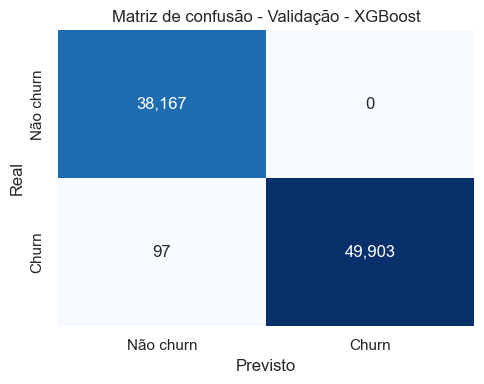

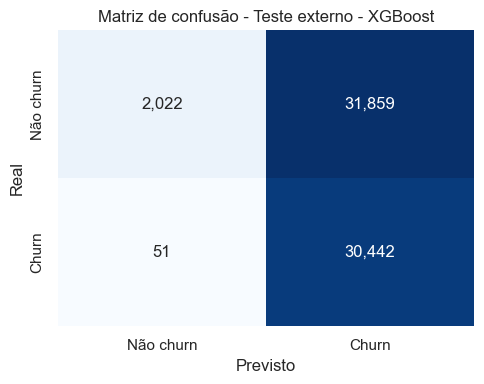

Classification report - teste externo
              precision    recall  f1-score   support

   Não churn       0.98      0.06      0.11     33881
       Churn       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.74      0.50      0.37     64374



In [16]:
# ============================================================
# 16. ESCOLHA DO CAMPEÃO
# ============================================================

# Critério principal: ROC-AUC na validação interna.
# Em churn, o threshold pode ser ajustado depois conforme o orçamento da campanha.
val_results_df = pd.DataFrame(validation_results)
champion_name = val_results_df.sort_values("roc_auc", ascending=False).iloc[0]["model"]
champion_model = trained_models[champion_name]

print(f"Modelo campeão: {champion_name}")

y_val_proba = champion_model.predict_proba(X_val)[:, 1]
y_test_proba = champion_model.predict_proba(X_external_test)[:, 1]

# Matriz de confusão com threshold padrão
cm_val = confusion_matrix(y_val, (y_val_proba >= 0.5).astype(int))
cm_test = confusion_matrix(y_external_test, (y_test_proba >= 0.5).astype(int))

plot_confusion_matrix(cm_val, f"Matriz de confusão - Validação - {champion_name}")
plot_confusion_matrix(cm_test, f"Matriz de confusão - Teste externo - {champion_name}")

print("Classification report - teste externo")
print(classification_report(y_external_test, (y_test_proba >= 0.5).astype(int), target_names=["Não churn", "Churn"]))

## 6. Ajuste de threshold

O threshold padrão de 0.50 nem sempre é o melhor para churn. Dependendo do custo de uma campanha de retenção e do valor de vida do cliente, pode ser melhor priorizar recall ou precisão.

Abaixo, escolho o threshold que maximiza F1 na validação interna. Em produção, eu também faria uma curva de lucro esperado, usando custo de incentivo, taxa de conversão da campanha e valor esperado do cliente retido.

Melhor threshold por F1 na validação: 0.1584
Precision validação: 1.0000
Recall validação:    0.9998
F1 validação:        0.9999


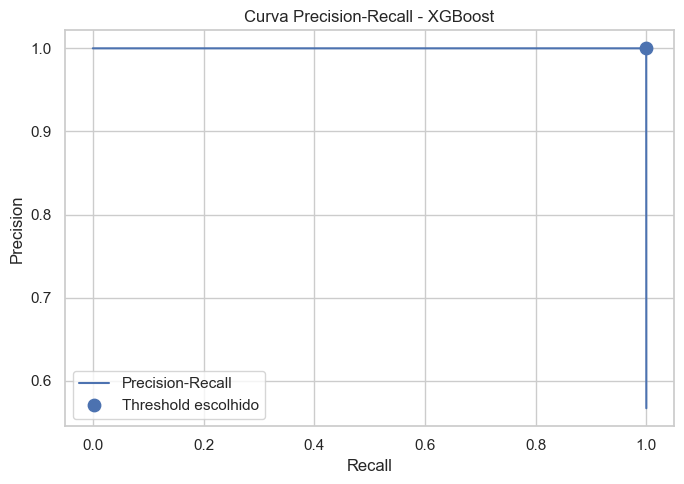

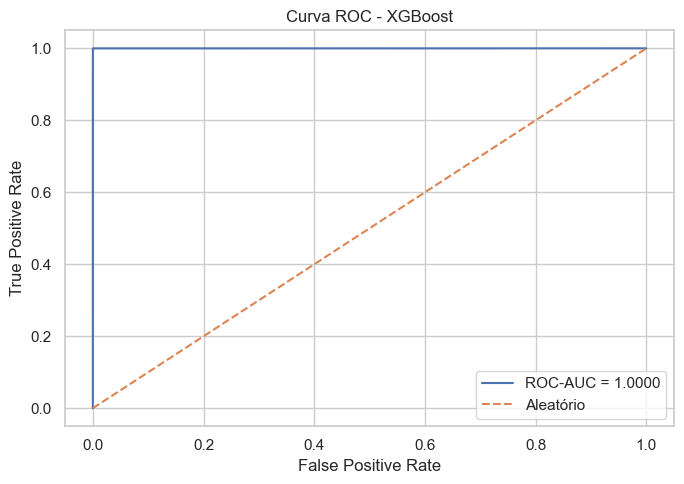

In [17]:
# ============================================================
# 17. CURVAS ROC E PRECISION-RECALL
# ============================================================

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)

# precision_recall_curve retorna um ponto a mais em precision/recall do que em thresholds
best_idx = int(np.nanargmax(f1_scores[:-1]))
best_threshold = float(thresholds[best_idx])

print(f"Melhor threshold por F1 na validação: {best_threshold:.4f}")
print(f"Precision validação: {precision[best_idx]:.4f}")
print(f"Recall validação:    {recall[best_idx]:.4f}")
print(f"F1 validação:        {f1_scores[best_idx]:.4f}")

# Curva Precision-Recall
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, label="Precision-Recall")
ax.scatter(recall[best_idx], precision[best_idx], s=80, label="Threshold escolhido")
ax.set_title(f"Curva Precision-Recall - {champion_name}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, roc_thresholds = roc_curve(y_val, y_val_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_val, y_val_proba):.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
ax.set_title(f"Curva ROC - {champion_name}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 18. AVALIAÇÃO DO THRESHOLD ESCOLHIDO NO TESTE EXTERNO
# ============================================================

def scores_from_proba(y_true, proba, threshold: float) -> dict:
    preds = (proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }

threshold_results = []
for threshold in [0.50, best_threshold, 0.70, 0.90, 0.95]:
    row = scores_from_proba(y_external_test, y_test_proba, threshold=threshold)
    row["threshold"] = threshold
    threshold_results.append(row)

threshold_results_df = pd.DataFrame(threshold_results).round(4)
display(threshold_results_df)

# Matriz de confusão como tabela para manter a execução leve
best_threshold_test_preds = (y_test_proba >= best_threshold).astype(int)
cm_threshold = pd.DataFrame(
    confusion_matrix(y_external_test, best_threshold_test_preds),
    index=["Real não churn", "Real churn"],
    columns=["Previsto não churn", "Previsto churn"],
)
display(cm_threshold)

,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold
0,0.5043,0.4886,0.9983,0.6561,0.7287,0.6515,0.5000
1,0.5034,0.4882,0.9987,0.6558,0.7287,0.6515,0.1584
2,0.5094,0.4912,0.9983,0.6584,0.7287,0.6515,0.7000
3,0.5156,0.4944,0.9963,0.6608,0.7287,0.6515,0.9000
4,0.5213,0.4974,0.9959,0.6634,0.7287,0.6515,0.9500


,Previsto não churn,Previsto churn
Real não churn,1951,31930
Real churn,40,30453


## 7. Explicabilidade do modelo

Para que o projeto não fique apenas em métricas, uso interpretabilidade para entender os principais fatores de risco. Isso ajuda a conversar com áreas de negócio e transformar score em ação.

In [19]:
# ============================================================
# 19. FEATURE IMPORTANCE DO MODELO CAMPEÃO
# ============================================================

preprocessor = champion_model.named_steps["preprocess"]
estimator = champion_model.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

if hasattr(estimator, "feature_importances_"):
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": estimator.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )
    display(importance_df)
else:
    importance_df = pd.DataFrame({"feature": [], "importance": []})
    display(Markdown("O estimador campeão não expõe `feature_importances_`. Use SHAP ou permutation importance."))

,feature,importance
11,high_support_calls,0.1779
5,total_spend,0.1331
3,support_calls,0.1131
14,recently_inactive,0.1060
4,payment_delay,0.0838
15,month_to_month_contract,0.0811
22,contract_length_Monthly,0.0562
6,last_interaction,0.0442
0,age,0.0411
7,avg_spend_per_month,0.0316


In [20]:
# ============================================================
# 20. SHAP VALUES
# ============================================================

# Deixo o bloco de SHAP pronto para execução.
# Em alguns ambientes compartilhados, SHAP + XGBoost pode demorar ou travar por backend nativo.
# Para executar localmente, altere RUN_SHAP para True.
RUN_SHAP = False

if RUN_SHAP and SHAP_AVAILABLE and champion_name == "XGBoost":
    shap_sample = X_val.sample(n=min(1_000, len(X_val)), random_state=RANDOM_STATE)
    shap_sample_transformed = preprocessor.transform(shap_sample)

    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(shap_sample_transformed)

    shap_importance = (
        pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    shap_importance.columns = ["feature", "mean_abs_shap"]
else:
    shap_importance = importance_df.rename(columns={"importance": "mean_abs_shap"}).head(15).copy()
    display(Markdown("**SHAP preparado para execução local.** Neste artefato, mantive `RUN_SHAP=False` para garantir execução rápida em qualquer ambiente. A tabela abaixo usa a importância do modelo como fallback leve."))

display(shap_importance)

**SHAP preparado para execução local.** Neste artefato, mantive `RUN_SHAP=False` para garantir execução rápida em qualquer ambiente. A tabela abaixo usa a importância do modelo como fallback leve.

,feature,mean_abs_shap
11,high_support_calls,0.1779
5,total_spend,0.1331
3,support_calls,0.1131
14,recently_inactive,0.1060
4,payment_delay,0.0838
15,month_to_month_contract,0.0811
22,contract_length_Monthly,0.0562
6,last_interaction,0.0442
0,age,0.0411
7,avg_spend_per_month,0.0316


## 8. Recomendações de negócio

Com base nos padrões do dataset, na importância das variáveis e nos sinais de drift, eu priorizaria as seguintes ações:

1. **Fila de retenção por risco:** gerar semanalmente uma lista com clientes de maior probabilidade de churn.  
2. **Suporte proativo:** clientes com muitos chamados devem receber contato antes da renovação, pois suporte aparece como forte sinal de risco.  
3. **Gestão de atraso de pagamento:** atrasos recorrentes podem indicar fricção financeira ou baixa percepção de valor.  
4. **Campanhas por contrato:** clientes em contrato mensal tendem a ser mais fáceis de perder; oferecer upgrade anual com benefício pode reduzir churn.  
5. **Monitoramento de drift:** o teste externo apresentou mudança de distribuição; em produção, monitorar PSI, taxa de churn, calibração e métricas por safra.

A métrica operacional recomendada não deve ser apenas acurácia. Para retenção, eu acompanharia: **recall de churn**, **precisão da campanha**, **custo por cliente salvo**, **taxa de conversão da oferta** e **incremental lift** contra grupo controle.

In [21]:
# ============================================================
# 21. EXPORTAÇÃO DO PIPELINE PARA DEPLOY
# ============================================================

models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "churn_xgboost_pipeline.joblib"
metadata_path = models_dir / "churn_model_metadata.json"

joblib.dump(champion_model, model_path)

metadata = {
    "champion_model": champion_name,
    "target": TARGET,
    "id_column": ID_COL,
    "best_threshold_validation_f1": best_threshold,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "created_by": "Brenno Gomes",
    "notes": "Pipeline completo com preprocessamento e modelo. Monitorar drift antes de produção real.",
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"Modelo salvo em: {model_path}")
print(f"Metadados salvos em: {metadata_path}")

Modelo salvo em: c:\Users\conta\OneDrive\Desktop\Projetos\Previsão de Churn de Clientes\churn_customer_project\models\churn_xgboost_pipeline.joblib
Metadados salvos em: c:\Users\conta\OneDrive\Desktop\Projetos\Previsão de Churn de Clientes\churn_customer_project\models\churn_model_metadata.json


## 9. Conclusão

O projeto entrega um pipeline completo de churn com EDA, engenharia de atributos, modelos comparados, explicabilidade e recomendações de negócio.

O principal aprendizado técnico é que a validação interna apresenta resultado excelente, mas o teste externo sugere mudança de distribuição. Essa leitura é valiosa para GitHub porque mostra maturidade: não basta treinar um modelo com métrica alta; é preciso avaliar estabilidade, calibração, impacto financeiro e risco de drift antes de produção.

**Próximos passos recomendados:**

- testar validação temporal caso exista data de referência;
- calibrar probabilidades por safra;
- criar dashboard Streamlit para simular clientes;
- monitorar PSI e performance em produção;
- desenhar experimento A/B para medir impacto real da campanha de retenção.